# BRAND HEALTH ANALYSIS — PORTFOLIO REPORT FOR COZY RTD TEA (2024-2025)

## BÁO CÁO ĐƯỢC CẤU TRÚC CHUẨN XÁC THEO 4 CHUYÊN ĐỀ:
1. **PHẦN 1: PHÂN TÍCH NHÂN KHẨU HỌC (Respondent Demographics)** — Phác họa chân dung đáp viên.
2. **PHẦN 2: PHÂN TÍCH HÀNH VI KHÁCH HÀNG (Consumer Behavior & Brand Health)** — Nhận biết, Thâm nhập & Phễu chuyển đổi thương hiệu.
3. **PHẦN 3: ĐỊNH VỊ HÌNH ẢNH THƯƠNG HIỆU (Brand Imagery)** — Sự liên tưởng hình ảnh và 18 thuộc tính thương hiệu.
4. **PHẦN 4: PHÂN TÍCH SẢN PHẨM & RÀO CẢN THƯƠNG HIỆU (Product Analysis & Barriers)** — Nguồn chuyển đổi và các rào cản cốt lõi về sản phẩm/phân phối của Cozy.


In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Cấu hình thẩm mỹ biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family'] = 'sans-serif'

# Khởi tạo đường dẫn dữ liệu sạch
PATH_DATA = '../output/Dataset_cleaned.csv'
PATH_BRAND = '../output/Brandlist_cleaned.csv'
PATH_QNR = '../output/QNR_Reference_cleaned.csv'

# Đọc dữ liệu sạch
df_clean = pd.read_csv(PATH_DATA, low_memory=False)
df_brand = pd.read_csv(PATH_BRAND)
df_qnr = pd.read_csv(PATH_QNR)

# Định nghĩa từ điển map SKU về Master Brand chuẩn xác
brand_to_master = {
    'C2': 'C2',
    'C2 - Không xác định': 'C2',
    'C2 - Vị chanh': 'C2',
    'C2 - Vị táo': 'C2',
    'C2 - Vị đào': 'C2',
    'C2 - Olong Hoa hồng': 'C2',
    'C2 - Olong Chanh': 'C2',
    'C2 – Hồng Trà': 'C2',
    'C2 – Hồng Trà Đào': 'C2',
    'C2 – Hồng Trà Vải': 'C2',
    'C2 – Freeze Hương chanh tuyết bạc hà': 'C2',
    'C2 – Freeze Hương dâu anh dào': 'C2',
    'C2 – Dưa lưới': 'C2',
    
    'OLong Tea Plus': 'OLong Tea Plus',
    'OLong Tea Plus.1': 'OLong Tea Plus',
    'OLong Tea Plus vị chanh': 'OLong Tea Plus',
    'Trà xanh matcha Tea Plus': 'OLong Tea Plus',
    
    'Không Độ': 'Không Độ',
    'Không Độ - Không xác định': 'Không Độ',
    'Không Độ - Vị chanh': 'Không Độ',
    'Không Độ - Bí đao': 'Không Độ',
    
    'Trà Cozy đóng chai': 'Trà Cozy đóng chai',
    'Trà Cozy Olong Xoài': 'Trà Cozy đóng chai',
    'Trà Cozy Vải': 'Trà Cozy đóng chai',
    'Trà Cozy Đào Sả': 'Trà Cozy đóng chai',
    
    'Dr. Thanh': 'Dr. Thanh',
    'Dr. Thanh - Không xác định': 'Dr. Thanh',
    'Dr. Thanh - Có đường': 'Dr. Thanh',
    'Dr. Thanh - Không đường': 'Dr. Thanh',
    
    'Trà Tea Go': 'Trà Tea Go',
    'Trà Tea Go – Vị Đào': 'Trà Tea Go',
    'Trà Tea Go – Vị Chanh': 'Trà Tea Go',
    
    'Trà sữa ít đường Vinamilk Happy Milktea': 'Trà sữa ít đường Vinamilk Happy Milktea',
    'Trà sữa ít đường Vinamilk Happy Milktea.1': 'Trà sữa ít đường Vinamilk Happy Milktea',
    
    'Trà lá vối Seventy': 'Trà lá vối Seventy',
    'Trà lá vối Seventy.1': 'Trà lá vối Seventy',
    
    'Trà thảo mộc VietFuji': 'Trà thảo mộc VietFuji',
    
    'Trà sữa không độ/ Trà sữa Macchiato': 'Trà sữa không độ/ Trà sữa Macchiato',
    'Trà sữa không độ/ Trà sữa Macchiato.1': 'Trà sữa không độ/ Trà sữa Macchiato',
    
    'Trà TH True Tea': 'Trà TH True Tea',
    'TH True Tea – Trà Oolong Tự Nhiên': 'Trà TH True Tea',
    'TH True Tea – Trà xanh vị chanh Tự Nhiên': 'Trà TH True Tea',
    
    'Trà mật ong Boncha': 'Trà mật ong Boncha',
    'Trà mật ong Boncha.1': 'Trà mật ong Boncha',
    'Trà mật ong Boncha vị chanh': 'Trà mật ong Boncha',
    
    'Trà Jokky': 'Trà Jokky',
    'Trà Jokky chanh sả': 'Trà Jokky',
    'Trà Jokky vị Đào': 'Trà Jokky',
    'Trà Jokky sâm': 'Trà Jokky',
    
    'Trà sữa C2': 'Trà sữa C2',
    
    'Búp non 365': 'Búp non 365',
    'Búp non 365 hương đào': 'Búp non 365',
    'Búp non 365 chanh sả': 'Búp non 365',
    'Búp non 365 mật ong': 'Búp non 365',
    'Búp non 365 mãng cầu': 'Búp non 365'
}

df_clean['tom_master'] = df_clean['Q1.TOM'].map(brand_to_master)
df_clean['bumo_master'] = df_clean['Q5.Bumo'].map(brand_to_master)

# Định nghĩa bảng màu theo đúng màu nhãn hàng Cozy:
# Màu chính (Forest Green): #156835, Màu phụ (Leaf Green): #3b903e
# Các đối thủ cạnh tranh sử dụng các tone màu Sage/Mint dịu mắt để đảm bảo Cozy luôn nổi bật nhất.
COZY_COLOR = '#156835'
COZY_LIGHT_COLOR = '#3b903e'
COMP_COLORS = ['#769276', '#8FA98F', '#A8C0A8', '#C1D7C1', '#DAEEDA', '#E8F5E8', '#F0FDF4']

print("✅ Setup, Load data & Master Brand Mapping completed successfully!")
print(f"   Dataset Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]:,} columns")


✅ Setup, Load data & Master Brand Mapping completed successfully!
   Dataset Shape: 2,600 rows × 1,070 columns


## PHẦN 1 — PHÂN TÍCH NHÂN KHẨU HỌC (Respondent Demographics)

**Câu hỏi & Ý nghĩa**:
Trước khi tiến hành phân tích chuyên sâu về sức khỏe thương hiệu, việc hiểu rõ đặc tính nhân khẩu học (Demographics) của mẫu là bắt buộc để đảm bảo tính đại diện và độ tin cậy của khảo sát. 
Chúng ta sẽ thực hiện trực quan hóa phân bổ mẫu nghiên cứu theo **4 chiều then chốt**: Khu vực địa lý (Region), Giới tính (Gender), Nhóm tuổi (Age group), và Thu nhập hộ gia đình (Income) qua hai năm khảo sát 2024 và 2025.

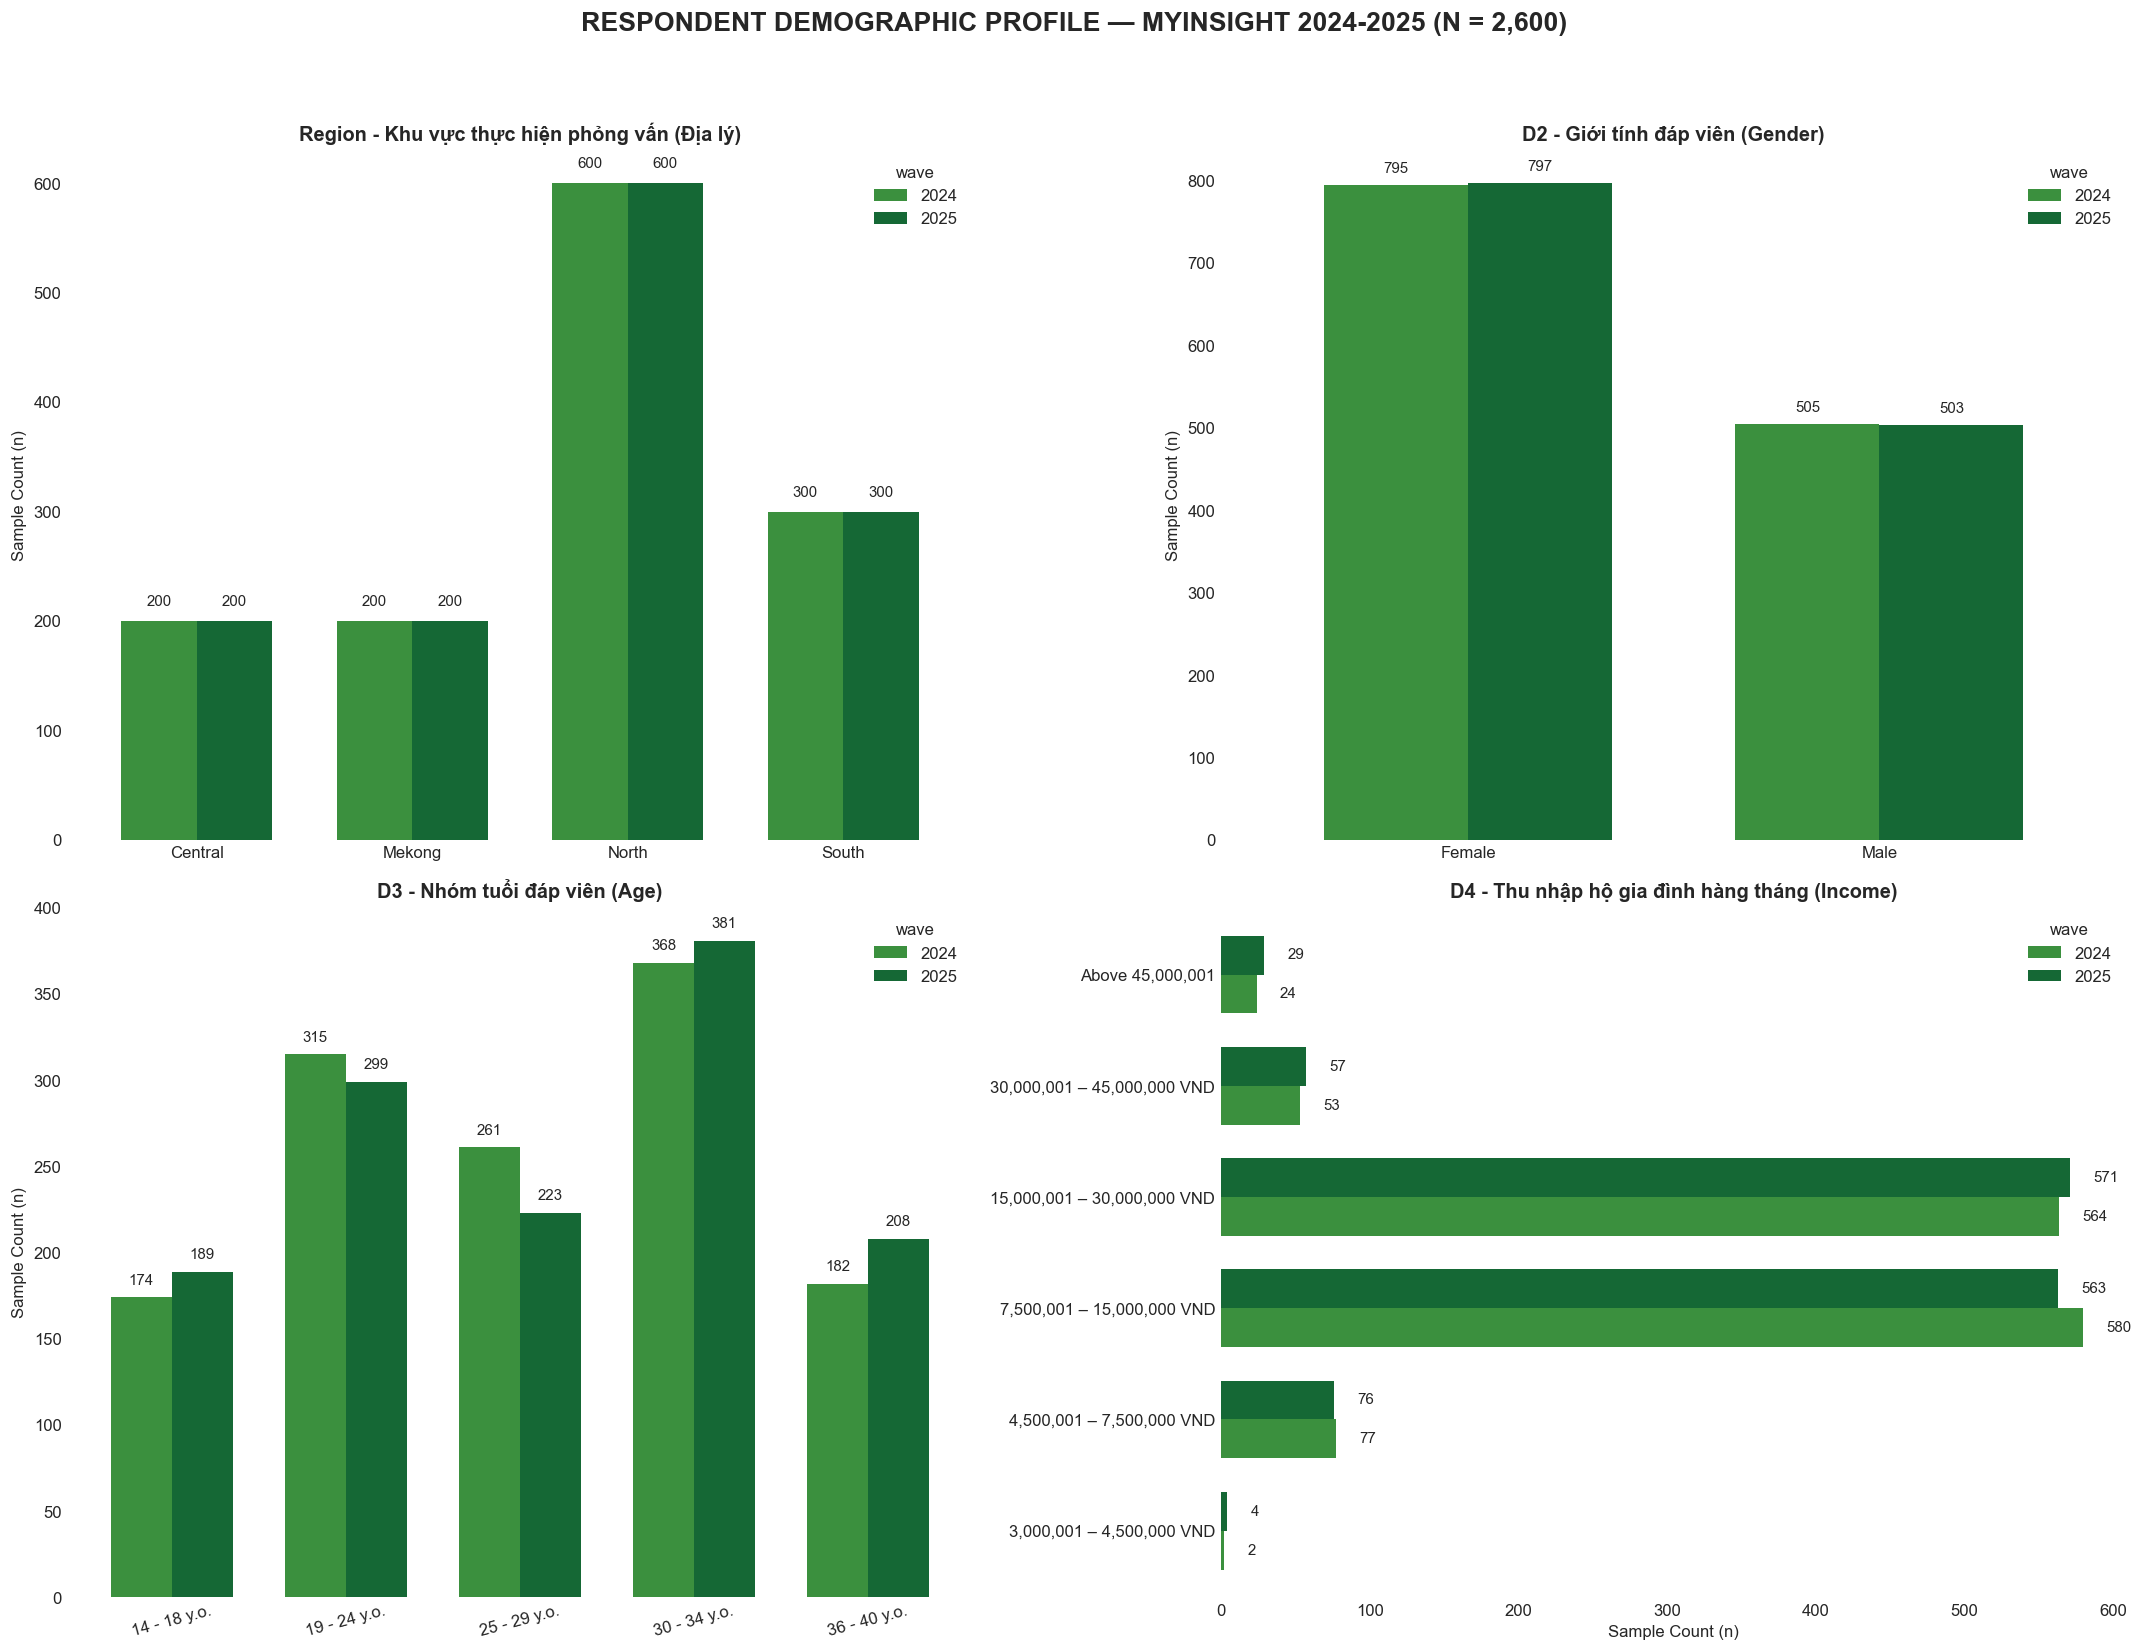

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
# Giả sử df_clean đã được định nghĩa ở trên

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('RESPONDENT DEMOGRAPHIC PROFILE — MYINSIGHT 2024-2025 (N = 2,600)', 
             fontsize=16, fontweight='bold', y=0.98)

# 1. Region Distribution by Wave
df_region = pd.crosstab(df_clean['region'], df_clean['wave'])
df_region.plot(kind='bar', ax=axes[0, 0], color=['#3b903e', '#156835'], width=0.7)
axes[0, 0].set_title('Region - Khu vực thực hiện phỏng vấn (Địa lý)', fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Sample Count (n)')
axes[0, 0].tick_params(axis='x', rotation=0)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2., p.get_height() + 10), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points')

# 2. Gender Distribution by Wave
df_gender = pd.crosstab(df_clean['gender'], df_clean['wave'])
df_gender.plot(kind='bar', ax=axes[0, 1], color=['#3b903e', '#156835'], width=0.7)
axes[0, 1].set_title('D2 - Giới tính đáp viên (Gender)', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Sample Count (n)')
axes[0, 1].tick_params(axis='x', rotation=0)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2., p.get_height() + 10), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points')

# 3. Age Group Distribution by Wave
df_age = pd.crosstab(df_clean['age_group'], df_clean['wave'])
df_age.plot(kind='bar', ax=axes[1, 0], color=['#3b903e', '#156835'], width=0.7)
axes[1, 0].set_title('D3 - Nhóm tuổi đáp viên (Age)', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Sample Count (n)')
axes[1, 0].tick_params(axis='x', rotation=15)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2., p.get_height() + 5), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points')

# 4. Income Distribution by Wave
df_income = pd.crosstab(df_clean['income'], df_clean['wave'])
# Reorder income levels
income_order = [
    '3,000,001 – 4,500,000 VND',
    '4,500,001 – 7,500,000 VND',
    '7,500,001 – 15,000,000 VND',
    '15,000,001 – 30,000,000 VND',
    '30,000,001 – 45,000,000 VND',
    'Above 45,000,001'
]
df_income = df_income.reindex(income_order)
df_income.plot(kind='barh', ax=axes[1, 1], color=['#3b903e', '#156835'], width=0.7)
axes[1, 1].set_title('D4 - Thu nhập hộ gia đình hàng tháng (Income)', fontweight='bold')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('Sample Count (n)')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_width():.0f}", (p.get_width() + 10, p.get_y() + p.get_height()/2.), 
                        ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')

# --- ĐOẠN CODE THÊM VÀO ĐỂ XÓA LƯỚI VÀ KHUNG ---
# Dùng axes.flat để áp dụng cho cả 4 biểu đồ con trong lưới 2x2
for ax in axes.flat:
    ax.grid(False) # Tắt lưới
    for spine in ax.spines.values():
        spine.set_visible(False) # Tắt khung bao quanh
    ax.tick_params(bottom=False, left=False) # Tắt luôn các vạch chia nhỏ li ti
# -----------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## PHẦN 2 — PHÂN TÍCH HÀNH VI KHÁCH HÀNG (Consumer Behavior & Brand Health)

**Ý nghĩa & Các chỉ số phân tích**:
Khám phá sâu hành vi lựa chọn và sử dụng trà uống liền đóng chai của người tiêu dùng qua hai năm 2024 và 2025. Phần này bao gồm 3 phân tích trụ cột:
1. **Nhận biết thương hiệu (Brand Awareness)**: Đo lường qua TOM (Top-of-mind), Tự phát (Spontaneous) và Có gợi ý (Aided).
2. **Thâm nhập thị trường (Penetration & Usage)**: Đo lường qua Dùng thử 3 tháng (P3M), Tiêu dùng 4 tuần (P4W) và Độ trung thành (BUMO).
3. **Phễu sức khỏe thương hiệu (Brand Funnel)**: Khám phá tỷ lệ chuyển đổi chặng từ Nhận biết ➔ Cân nhắc ➔ Dùng thử ➔ Thường xuyên ➔ Trung thành.

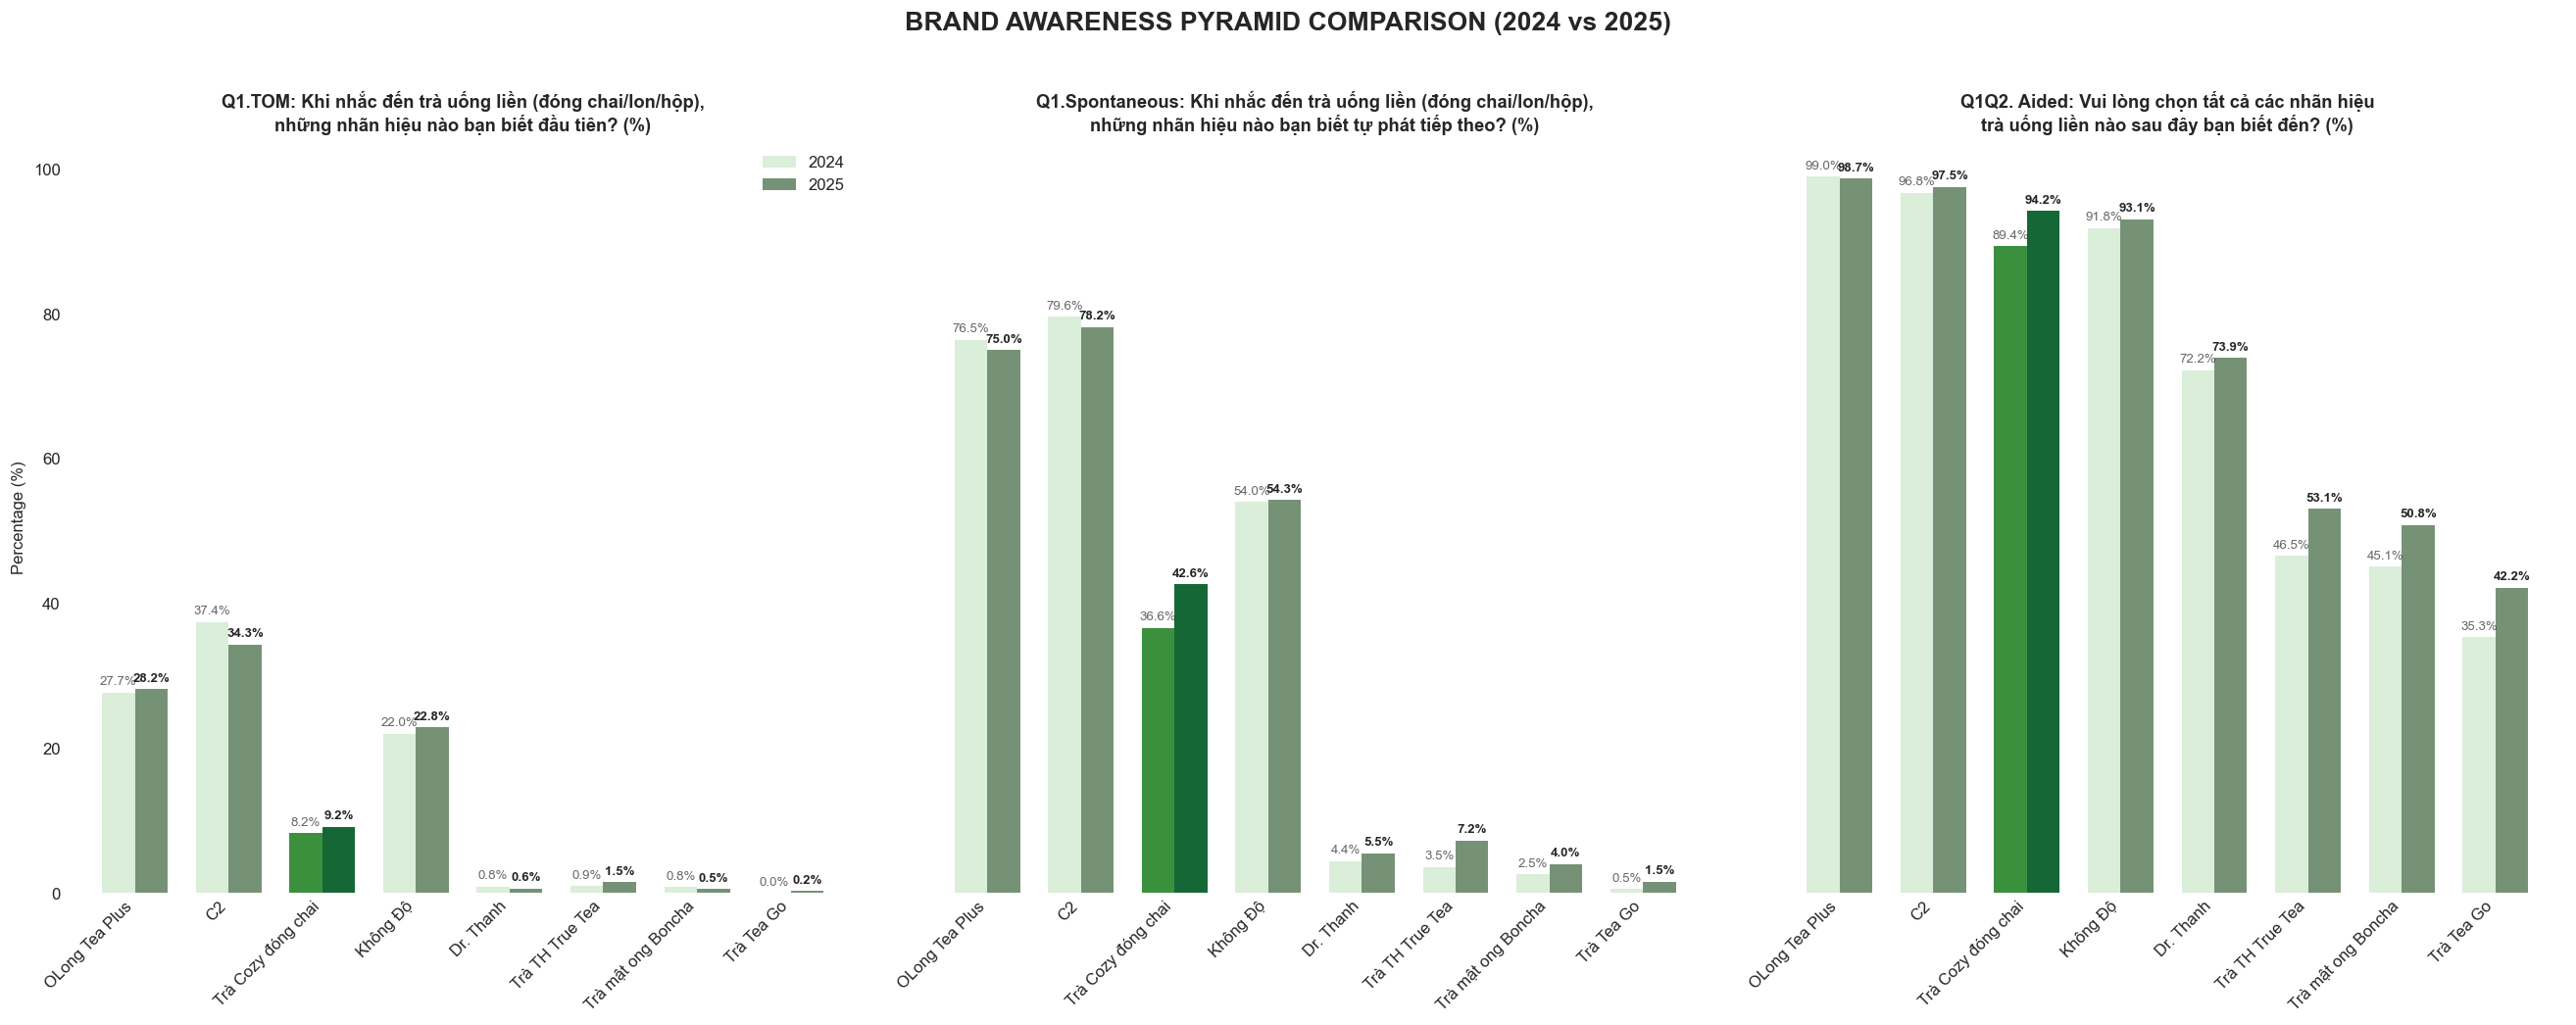

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_brands = [
    'C2',
    'OLong Tea Plus',
    'Không Độ',
    'Trà Cozy đóng chai',
    'Trà mật ong Boncha',
    'Trà TH True Tea',
    'Dr. Thanh',
    'Trà Tea Go'
]

results_2024 = []
results_2025 = []

df_24 = df_clean[df_clean['wave'] == 2024]
df_25 = df_clean[df_clean['wave'] == 2025]

for b in target_brands:

    tom_24 = (df_24['tom_master'] == b).mean() * 100

    spon_24 = (
        df_24[f'Q1.Total Spontaneous_{b}'].mean() * 100
        if f'Q1.Total Spontaneous_{b}' in df_24.columns
        else 0.0
    )

    aided_24 = (
        df_24[f'Q1Q2. Total aided awareness_{b}'].mean() * 100
        if f'Q1Q2. Total aided awareness_{b}' in df_24.columns
        else 0.0
    )

    results_2024.append({
        'Brand': b,
        'TOM': tom_24,
        'Spontaneous': spon_24,
        'Aided': aided_24
    })

    tom_25 = (df_25['tom_master'] == b).mean() * 100

    spon_25 = (
        df_25[f'Q1.Total Spontaneous_{b}'].mean() * 100
        if f'Q1.Total Spontaneous_{b}' in df_25.columns
        else 0.0
    )

    aided_25 = (
        df_25[f'Q1Q2. Total aided awareness_{b}'].mean() * 100
        if f'Q1Q2. Total aided awareness_{b}' in df_25.columns
        else 0.0
    )

    results_2025.append({
        'Brand': b,
        'TOM': tom_25,
        'Spontaneous': spon_25,
        'Aided': aided_25
    })

df_aw_24 = pd.DataFrame(results_2024).set_index('Brand')
df_aw_25 = pd.DataFrame(results_2025).set_index('Brand')

df_aw_25 = df_aw_25.sort_values(by='Aided', ascending=False)
df_aw_24 = df_aw_24.reindex(df_aw_25.index)

fig, axes = plt.subplots(1, 3, figsize=(22, 8.5), sharey=True)

fig.suptitle(
    'BRAND AWARENESS PYRAMID COMPARISON (2024 vs 2025)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

metrics = ['TOM', 'Spontaneous', 'Aided']

titles = [
    'Q1.TOM: Khi nhắc đến trà uống liền (đóng chai/lon/hộp),\nnhững nhãn hiệu nào bạn biết đầu tiên? (%)',

    'Q1.Spontaneous: Khi nhắc đến trà uống liền (đóng chai/lon/hộp),\nnhững nhãn hiệu nào bạn biết tự phát tiếp theo? (%)',

    'Q1Q2. Aided: Vui lòng chọn tất cả các nhãn hiệu\ntrà uống liền nào sau đây bạn biết đến? (%)'
]

for i, metric in enumerate(metrics):

    plot_df = pd.DataFrame({
        '2024': df_aw_24[metric],
        '2025': df_aw_25[metric]
    })

    colors_2024 = [
        COZY_LIGHT_COLOR if b == 'Trà Cozy đóng chai' else '#DAEEDA'
        for b in plot_df.index
    ]

    colors_2025 = [
        COZY_COLOR if b == 'Trà Cozy đóng chai' else '#769276'
        for b in plot_df.index
    ]

    x = np.arange(len(plot_df.index))
    width = 0.35

    rects1 = axes[i].bar(
        x - width / 2,
        plot_df['2024'],
        width,
        label='2024',
        color=colors_2024
    )

    rects2 = axes[i].bar(
        x + width / 2,
        plot_df['2025'],
        width,
        label='2025',
        color=colors_2025
    )

    axes[i].set_title(
        titles[i],
        fontweight='bold',
        fontsize=11
    )

    axes[i].set_xticks(x)

    axes[i].set_xticklabels(
        plot_df.index,
        rotation=45,
        ha='right',
        fontsize=10
    )

    # XÓA LƯỚI
    axes[i].grid(False)

    # XÓA KHUNG
    for spine in axes[i].spines.values():
        spine.set_visible(False)

    # HIỂN THỊ % NĂM 2025
    for rect, val in zip(rects2, plot_df['2025']):

        axes[i].annotate(
            f"{val:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, val),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

    # HIỂN THỊ % NĂM 2024
    for rect, val in zip(rects1, plot_df['2024']):

        axes[i].annotate(
            f"{val:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, val),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            alpha=0.7
        )

axes[0].set_ylabel('Percentage (%)')

axes[0].legend(frameon=False)

plt.tight_layout()

plt.show()

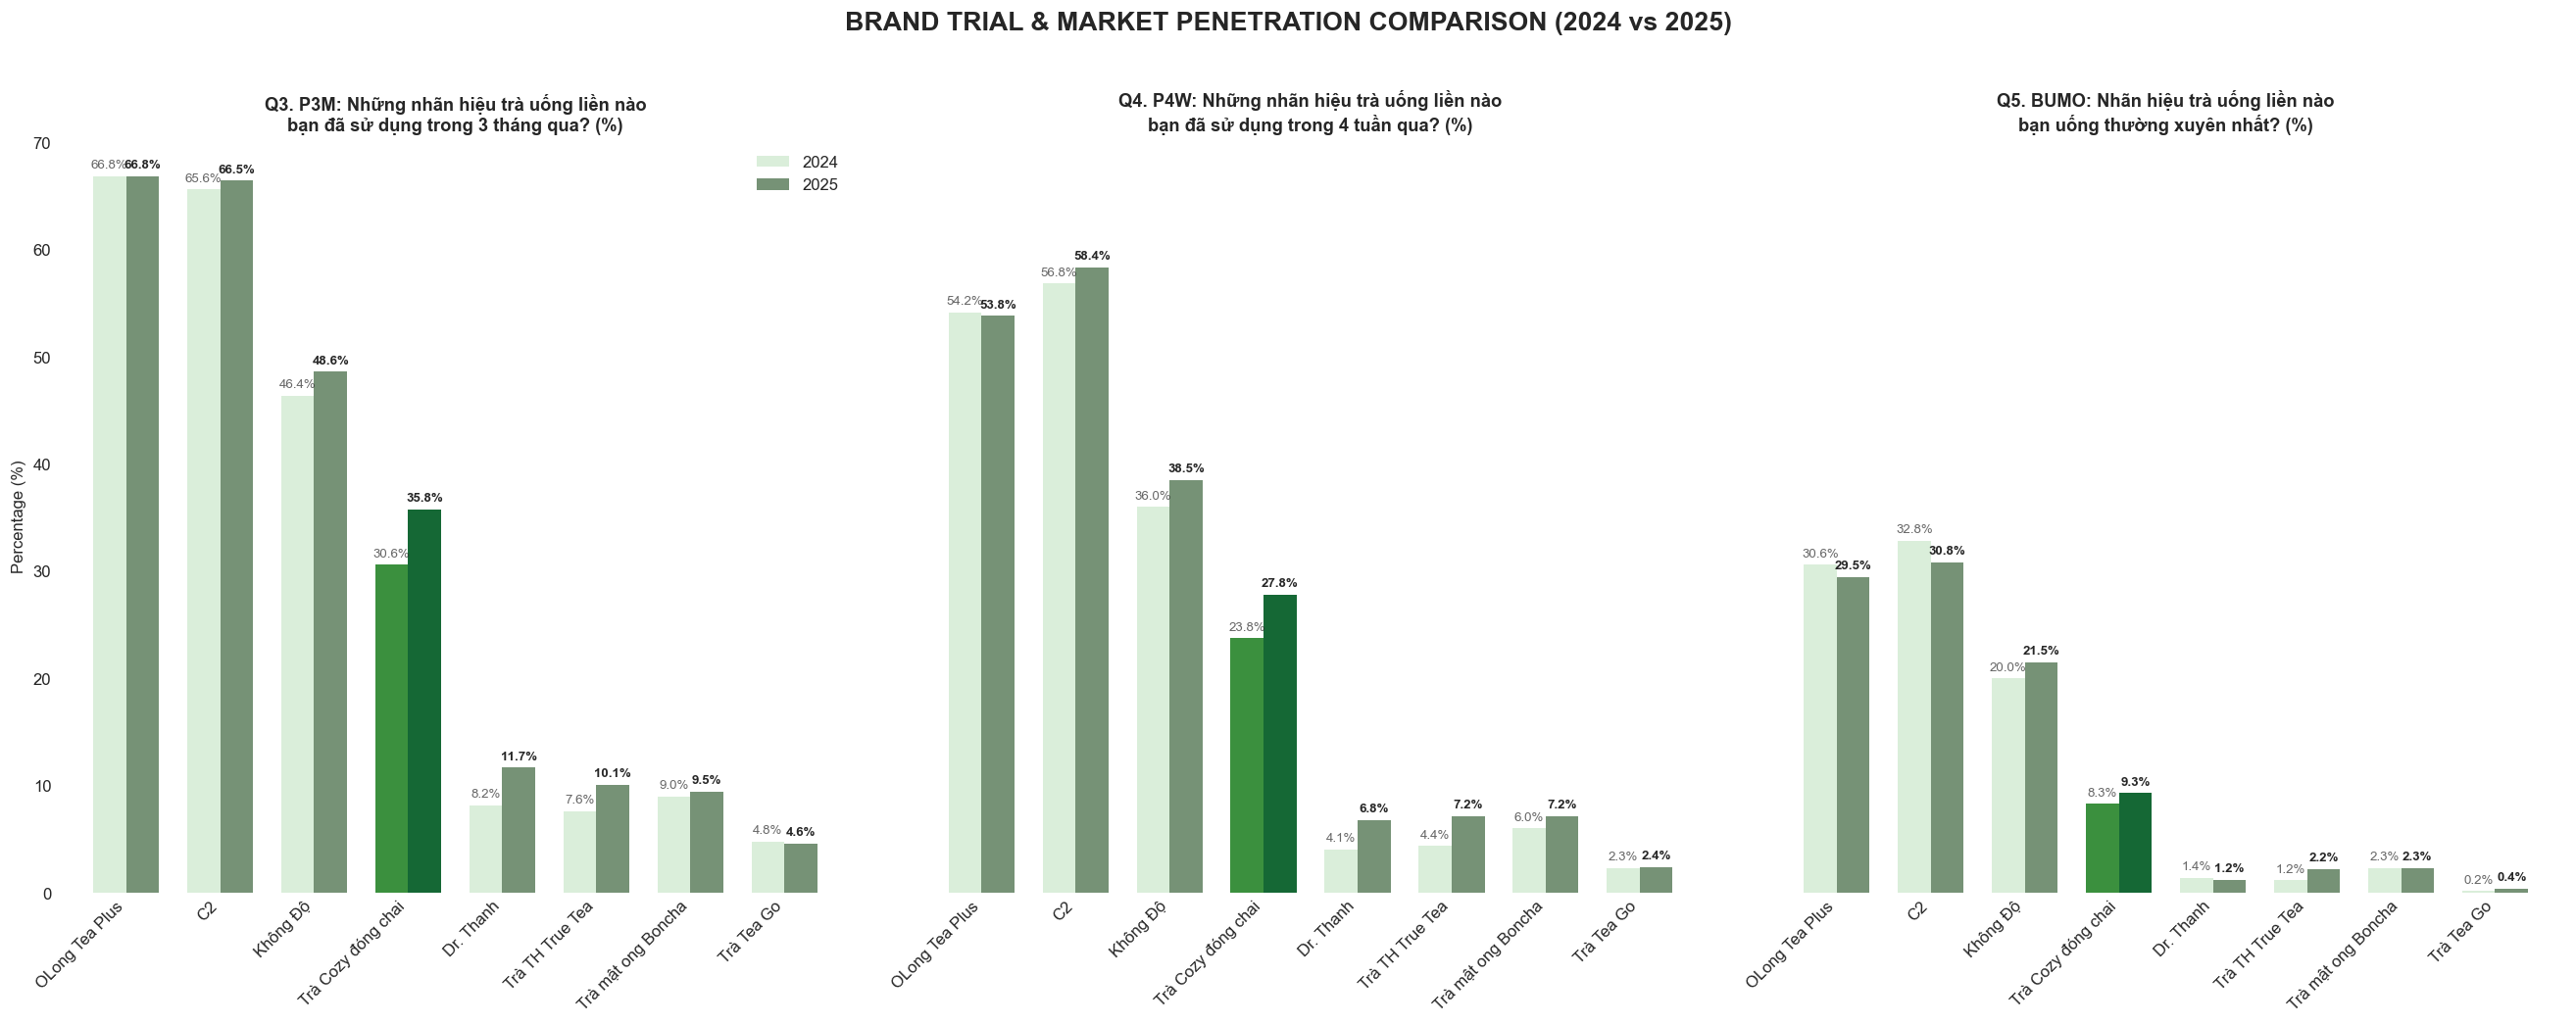

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_use_24 = []
results_use_25 = []

for b in target_brands:

    if b == 'C2':
        p4w_cols = [
            c for c in df_clean.columns
            if c.startswith('Q4. P4W_C2') and 'Trà sữa C2' not in c
        ]

    elif b == 'OLong Tea Plus':
        p4w_cols = [
            c for c in df_clean.columns
            if 'OLong Tea Plus' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Không Độ':
        p4w_cols = [
            c for c in df_clean.columns
            if 'Không Độ' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Trà Cozy đóng chai':
        p4w_cols = [
            c for c in df_clean.columns
            if 'Cozy' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Dr. Thanh':
        p4w_cols = [
            c for c in df_clean.columns
            if 'Dr. Thanh' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Trà Tea Go':
        p4w_cols = [
            c for c in df_clean.columns
            if 'Tea Go' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Trà TH True Tea':
        p4w_cols = [
            c for c in df_clean.columns
            if 'TH True Tea' in c and c.startswith('Q4. P4W_')
        ]

    elif b == 'Trà mật ong Boncha':
        p4w_cols = [
            c for c in df_clean.columns
            if 'Boncha' in c and c.startswith('Q4. P4W_')
        ]

    else:
        p4w_cols = []

    # 2024
    p3m_24 = (
        df_24[f'Q3. P3M _{b}'].mean() * 100
        if f'Q3. P3M _{b}' in df_24.columns
        else 0.0
    )

    p4w_24 = (
        df_24[p4w_cols].max(axis=1).mean() * 100
        if p4w_cols
        else 0.0
    )

    bumo_24 = (df_24['bumo_master'] == b).mean() * 100

    results_use_24.append({
        'Brand': b,
        'P3M': p3m_24,
        'P4W': p4w_24,
        'BUMO': bumo_24
    })

    # 2025
    p3m_25 = (
        df_25[f'Q3. P3M _{b}'].mean() * 100
        if f'Q3. P3M _{b}' in df_25.columns
        else 0.0
    )

    p4w_25 = (
        df_25[p4w_cols].max(axis=1).mean() * 100
        if p4w_cols
        else 0.0
    )

    bumo_25 = (df_25['bumo_master'] == b).mean() * 100

    results_use_25.append({
        'Brand': b,
        'P3M': p3m_25,
        'P4W': p4w_25,
        'BUMO': bumo_25
    })

# DATAFRAME
df_use_24 = pd.DataFrame(results_use_24).set_index('Brand')
df_use_25 = pd.DataFrame(results_use_25).set_index('Brand')

# SORT
df_use_25 = df_use_25.sort_values(by='P3M', ascending=False)
df_use_24 = df_use_24.reindex(df_use_25.index)

# PLOT
fig, axes = plt.subplots(1, 3, figsize=(22, 8.5), sharey=True)

fig.suptitle(
    'BRAND TRIAL & MARKET PENETRATION COMPARISON (2024 vs 2025)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

use_metrics = ['P3M', 'P4W', 'BUMO']

use_titles = [
    'Q3. P3M: Những nhãn hiệu trà uống liền nào\nbạn đã sử dụng trong 3 tháng qua? (%)',

    'Q4. P4W: Những nhãn hiệu trà uống liền nào\nbạn đã sử dụng trong 4 tuần qua? (%)',

    'Q5. BUMO: Nhãn hiệu trà uống liền nào\nbạn uống thường xuyên nhất? (%)'
]

for i, metric in enumerate(use_metrics):

    plot_df = pd.DataFrame({
        '2024': df_use_24[metric],
        '2025': df_use_25[metric]
    })

    x = np.arange(len(plot_df.index))
    width = 0.35

    colors_2024 = [
        COZY_LIGHT_COLOR if b == 'Trà Cozy đóng chai'
        else '#DAEEDA'
        for b in plot_df.index
    ]

    colors_2025 = [
        COZY_COLOR if b == 'Trà Cozy đóng chai'
        else '#769276'
        for b in plot_df.index
    ]

    rects1 = axes[i].bar(
        x - width / 2,
        plot_df['2024'],
        width,
        label='2024',
        color=colors_2024
    )

    rects2 = axes[i].bar(
        x + width / 2,
        plot_df['2025'],
        width,
        label='2025',
        color=colors_2025
    )

    axes[i].set_title(
        use_titles[i],
        fontweight='bold',
        fontsize=11
    )

    axes[i].set_xticks(x)

    axes[i].set_xticklabels(
        plot_df.index,
        rotation=45,
        ha='right',
        fontsize=10
    )

    # XÓA LƯỚI
    axes[i].grid(False)

    # XÓA KHUNG
    for spine in axes[i].spines.values():
        spine.set_visible(False)

    # LABEL 2025
    for rect, val in zip(rects2, plot_df['2025']):

        axes[i].annotate(
            f"{val:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, val),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

    # LABEL 2024
    for rect, val in zip(rects1, plot_df['2024']):

        axes[i].annotate(
            f"{val:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, val),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8,
            alpha=0.7
        )

axes[0].set_ylabel('Percentage (%)')

axes[0].legend(frameon=False)

plt.tight_layout()

plt.show()

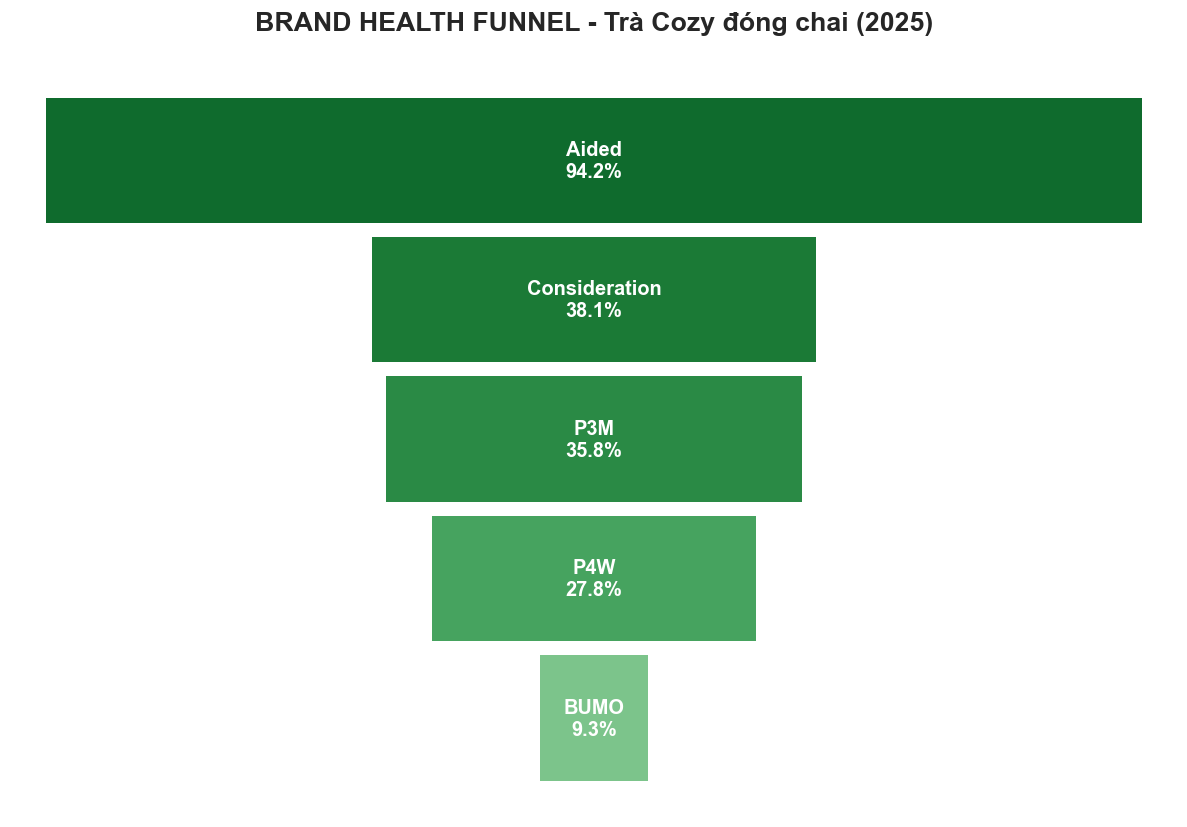

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# DATA
stages = ['Aided', 'Consideration', 'P3M', 'P4W', 'BUMO']

values = [94.2, 38.1, 35.8, 27.8, 9.3]

# MÀU
colors = [
    '#0F6B2D',
    '#1B7A36',
    '#2A8A45',
    '#46A35F',
    '#7CC48B'
]

fig, ax = plt.subplots(figsize=(10, 7))

# VẼ FUNNEL
for i, (stage, val) in enumerate(zip(stages, values)):

    left = (100 - val) / 2

    ax.barh(
        y=i,
        width=val,
        left=left,
        height=0.9,
        color=colors[i]
    )

    # LABEL %
    ax.text(
        50,
        i,
        f"{stage}\n{val:.1f}%",
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'
    )

# STYLE
ax.set_xlim(0, 100)

ax.invert_yaxis()

ax.set_xticks([])
ax.set_yticks([])

# XÓA KHUNG
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    'BRAND HEALTH FUNNEL - Trà Cozy đóng chai (2025)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

plt.show()

## PHẦN 3 — ĐỊNH VỊ HÌNH ẢNH THƯƠNG HIỆU (Brand Imagery & Attribute Association)

**Câu hỏi & Ý nghĩa**:
Thương hiệu đại diện cho điều gì trong tâm trí khách hàng? 
Khảo sát đánh giá **18 thuộc tính hình ảnh thương hiệu** từ R1 đến R18 (Nhóm cột `QI`). 
Chúng ta vẽ **Bản đồ nhiệt liên tưởng thuộc tính (Brand Attribute Heatmap)** so sánh Cozy với 3 đối thủ C2, OLong Tea Plus, và Không Độ để định vị chính xác vị thế hình ảnh của Cozy.

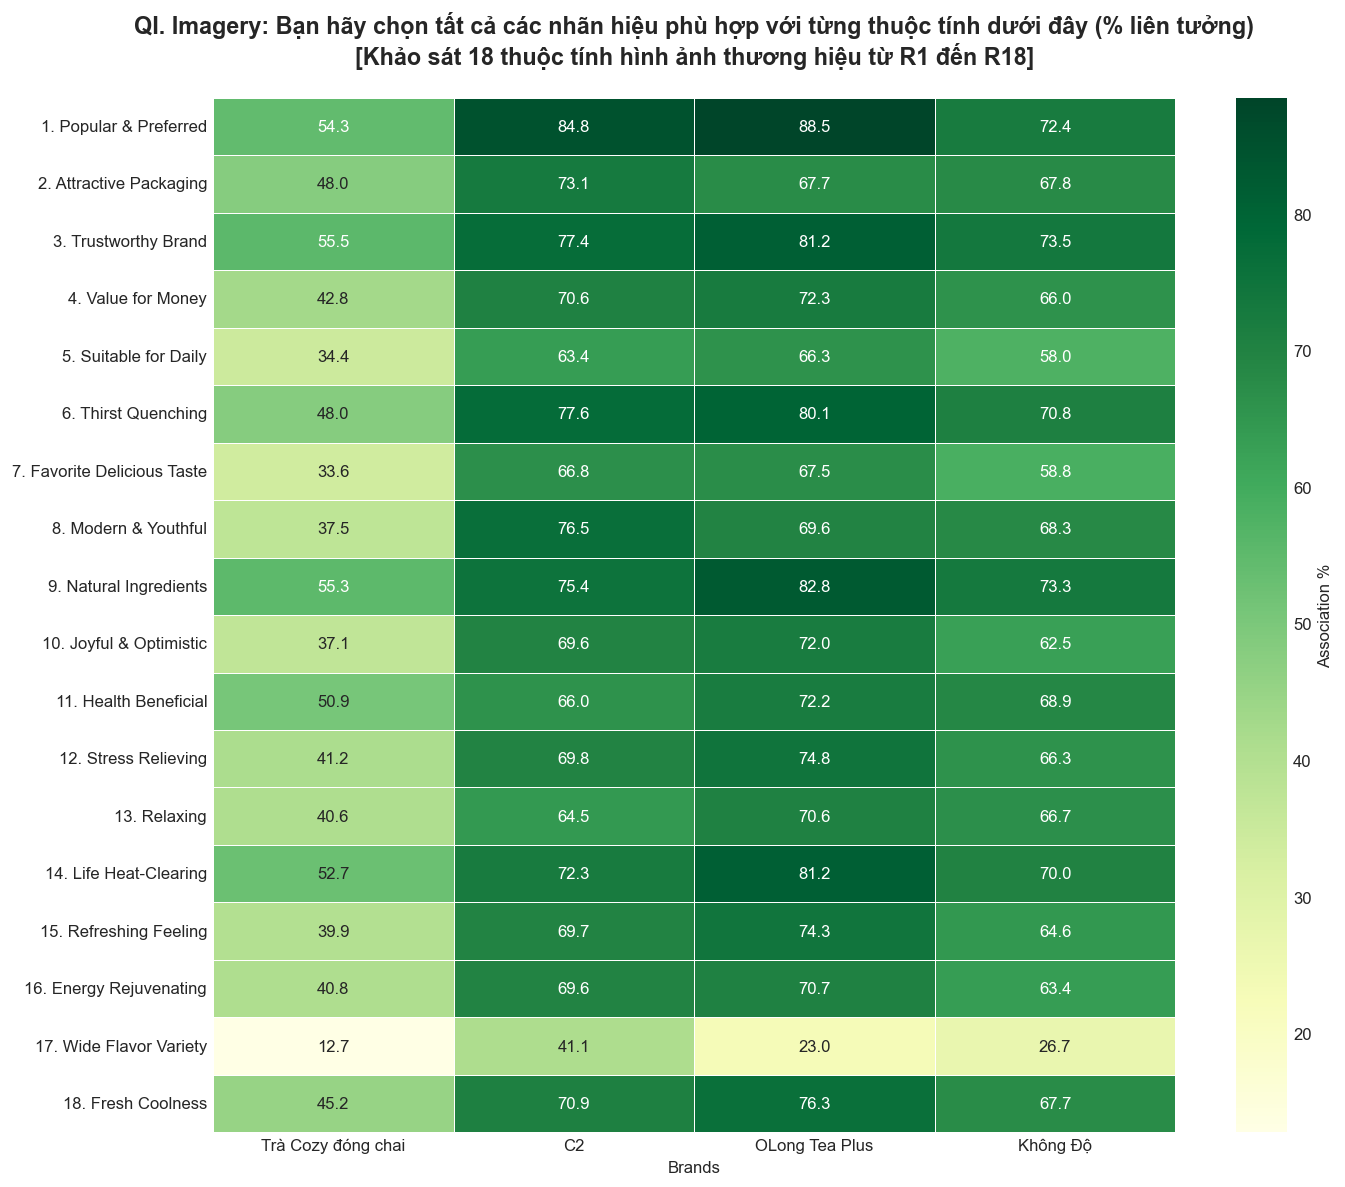

In [48]:
attributes_viet = {
    'Những thương hiệu được ưa chuộng và phổ biến': '1. Popular & Preferred',
    'Bao bì có thiết kế thu hút': '2. Attractive Packaging',
    'Nhãn hiệu đáng tin cậy': '3. Trustworthy Brand',
    'Giá cả hợp lý với chất lượng mang lại': '4. Value for Money',
    'Phù hợp để thưởng thức hàng ngày': '5. Suitable for Daily',
    'Làm dịu cơn khát': '6. Thirst Quenching',
    'Vị ngon mà tôi yêu thích': '7. Favorite Delicious Taste',
    'Thương hiệu mang tính hiện đại, trẻ trung': '8. Modern & Youthful',
    'Sản xuất từ nguyên liệu tự nhiên': '9. Natural Ingredients',
    'Mang đến sự vui tươi và lạc quan': '10. Joyful & Optimistic',
    'Có lợi cho sức khỏe': '11. Health Beneficial',
    'Giúp giảm căng thẳng và mệt mỏi': '12. Stress Relieving',
    'Mang lại cảm giác thư giãn': '13. Relaxing',
    'Giải nhiệt cuộc sống': '14. Life Heat-Clearing',
    'Tạo cảm giác sảng khoái': '15. Refreshing Feeling',
    'Tái tạo năng lượng': '16. Energy Rejuvenating',
    'Có nhiều vị để lựa chọn': '17. Wide Flavor Variety',
    'Mang đến cảm giác tươi mát': '18. Fresh Coolness'
}

results_img = []
for orig_attr, eng_attr in attributes_viet.items():
    row = {'Attribute': eng_attr}
    for b in funnel_brands:
        col = f'QI - {b}_{orig_attr}'
        if col in df_clean.columns:
            aided_col = f'Q1Q2. Total aided awareness_{b}'
            aware_respondents = df_clean[df_clean[aided_col] == 1]
            row[b] = aware_respondents[col].mean() * 100 if len(aware_respondents) > 0 else 0.0
        else:
            row[b] = 0.0
    results_img.append(row)

df_img = pd.DataFrame(results_img).set_index('Attribute')

plt.figure(figsize=(12, 10))
sns.heatmap(df_img, annot=True, fmt=".1f", cmap='YlGn', linewidths=0.5, cbar_kws={'label': 'Association %'})
plt.title('QI. Imagery: Bạn hãy chọn tất cả các nhãn hiệu phù hợp với từng thuộc tính dưới đây (% liên tưởng)\n[Khảo sát 18 thuộc tính hình ảnh thương hiệu từ R1 đến R18]', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('')
plt.xlabel('Brands')
plt.tight_layout()
plt.show()


## PHẦN 4 — PHÂN TÍCH SẢN PHẨM & RÀO CẢN THƯƠNG HIỆU (Product Analysis & Barriers)

**Câu hỏi & Ý nghĩa**:
Để Cozy thực sự bứt phá và giành giật thị phần, chúng ta phải thực hiện phân tích sâu về khía cạnh sản phẩm và rào cản tiêu dùng:
1. **Nguồn khách hàng của Cozy chuyển đổi từ đâu? (Switching Source Analysis)**: Phân tích xem người dùng Cozy BUMO hiện tại trước đó uống thương hiệu nào (Previous BUMO - Nhóm cột `Q7`).
2. **Các rào cản cụ thể đối với sản phẩm Cozy (Barriers Analysis)**: Tại sao khách hàng nhận biết Cozy nhưng kiên quyết không cân nhắc mua (Nhóm câu hỏi rào cản `Q.ME2`).

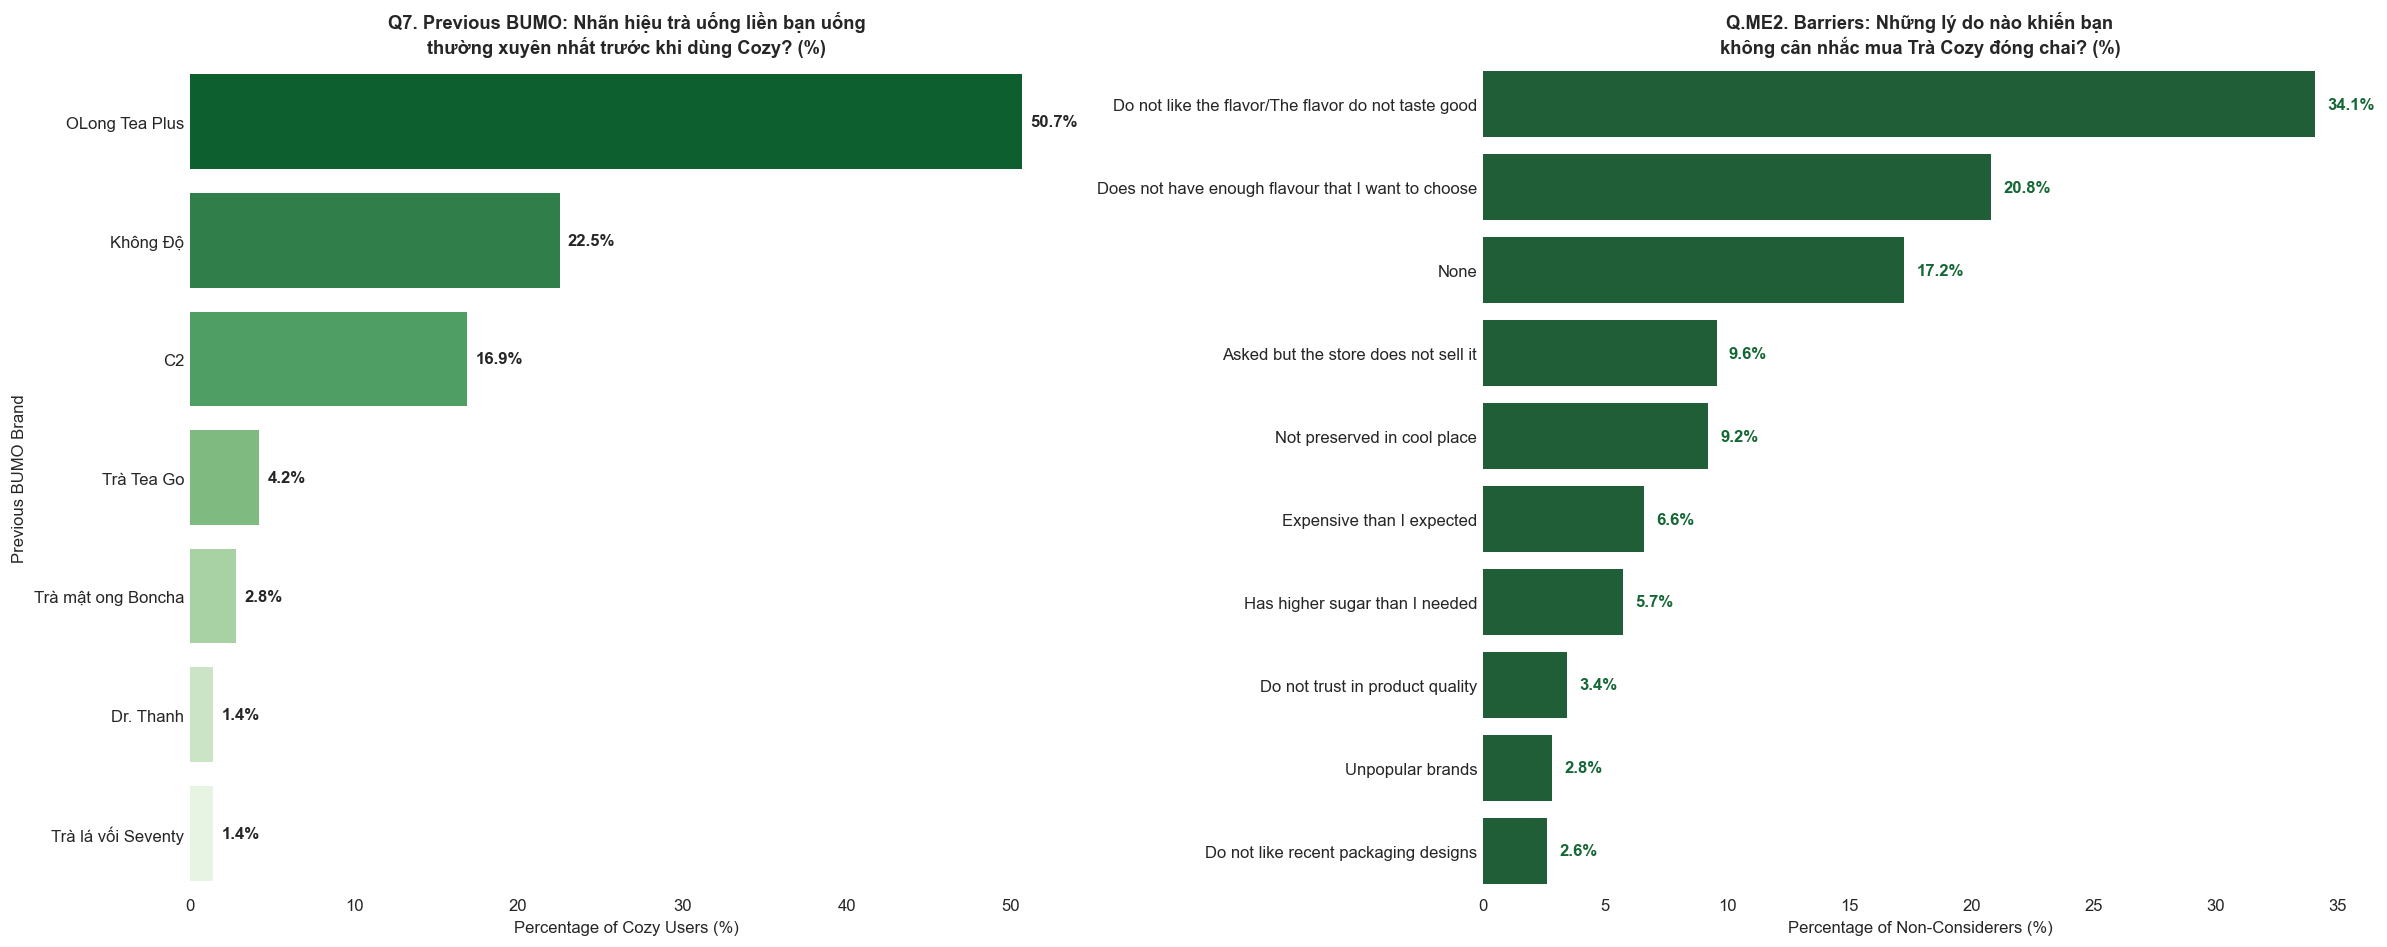

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Switching Source (Previous BUMO of current Cozy BUMO users)
df_cozy_bumo = df_clean[df_clean['bumo_master'] == 'Trà Cozy đóng chai']
switching_source = df_cozy_bumo['Q7. Previous BUMO'].value_counts(normalize=True) * 100

sns.barplot(x=switching_source.values, y=switching_source.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Q7. Previous BUMO: Nhãn hiệu trà uống liền bạn uống\nthường xuyên nhất trước khi dùng Cozy? (%)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Percentage of Cozy Users (%)')
axes[0].set_ylabel('Previous BUMO Brand')
for i, v in enumerate(switching_source.values):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

# 2. Barriers to considering Cozy (Q.ME2)
cozy_barrier_cols = [c for c in df_clean.columns if 'QME2 - Trà Cozy đóng chai' in c]
barriers_pct = {}
for col in cozy_barrier_cols:
    barrier_name = col.split('_')[-1]
    target_resp = df_clean[
        (df_clean['Q1Q2. Total aided awareness_Trà Cozy đóng chai'] == 1) &
        (df_clean['Q4Q8.BRAND CONSIDERATION SET_Trà Cozy đóng chai'] == 0)
    ]
    barriers_pct[barrier_name] = target_resp[col].mean() * 100 if len(target_resp) > 0 else 0.0

df_barriers = pd.Series(barriers_pct).sort_values(ascending=False).head(10)

sns.barplot(x=df_barriers.values, y=df_barriers.index, ax=axes[1], color=COZY_COLOR)
axes[1].set_title('Q.ME2. Barriers: Những lý do nào khiến bạn\nkhông cân nhắc mua Trà Cozy đóng chai? (%)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Percentage of Non-Considerers (%)')
axes[1].set_ylabel('')
for i, v in enumerate(df_barriers.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold', color=COZY_COLOR)

# --- ĐOẠN CODE THÊM VÀO ĐỂ XÓA LƯỚI VÀ KHUNG ---
for ax in axes:
    ax.grid(False) # Tắt lưới
    for spine in ax.spines.values():
        spine.set_visible(False) # Tắt toàn bộ đường viền khung
    ax.tick_params(bottom=False, left=False) # Tắt luôn các vạch chia nhỏ
# -----------------------------------------------

plt.tight_layout()
plt.show()